# 🔆 Overview
This notebook imports **final_df from "Data_cleaning_split.ipynb"**, splits the data into train/test sets, and builds a baseline model - a logistic regresion model. Here, we **predict the normal_range or not using the past 30-minute data** to predict the current range of glucose level. If the subgroup data has data from less than 30 minutes, we take in what is available. Also, for gaps larger than 30 minutes, we look back upto 60 minutes, the maximum value that the gaps can be.

* Note: due to the way that logistic regression models work, we take the statistics of past 30 minutes glucose levels and then use them as input features.

* Note: we do **not use synthetic data** here

**Train/test split**: time-based split
* For each ID, we use the first 80% of the timestamp for training, 20% for testing
* This approach preserves chronical order and avoids potential data leakage
* Here, we also check the class distribution in train set so that rare cases such as hypoglycemia don't end up just being in either set - which will ensure that the model will learn pattenrs for all classes
  
   1️⃣ time-based split per ID to avoid data leakage
  
   2️⃣ check the class distribution in train set
   
   3️⃣ if there's an unrepresented class, we oversample that class to balance the train/test sets
  
* **All canine subsets are in the train/test set, and there is no random sampling**

**Additional Weighting**
* To account for glucose levels that may have greater impact (e.g., those that were measured more recently would be more likely to be closer to the current data point), we apply weights in calculating the mean and the slope

**Model input** (7)
* **mean_glucose**: overall level of glucose within the past 30 minutes
* **min_glucose**: detects dips for hypoglycemia risk, *weighted*
* **max_glucose**: detects dips for hyperglycemia risk
* **last_glucose**: the most recent measurement as a short-term reference
* **slope**: aim to capture the overall trend in glucose fluctuation, *weighted*
* **mean_gap**: captures density of readings
  * for example, some data points might have 5 past data points within the 30-minute time window, while some points might have only 2 past data points to refer to
* gap_min: already in the data. used for indicating the time difference of the current time point with the most recent measure
* **num_readings**: number of readings in the past 30 minutes (or past 60 minutes if there are no readings from the past 30 minutes)

**Label**
: To allow for flexible change between predicting 'normal_range' and 'glucose_category', we set the label as 'target'




---

# 🔆 Setup / Importing Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

In [2]:
# mounting on gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import data
# WooJung
data_path = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228"

# Ainsley


# Ci


In [4]:
# importing data
file = os.path.join(data_path, "final_df.pkl")

try:
  with open(file, "rb") as f:
    final_df = pickle.load(f)
except FileNotFoundError:
  print(f"Error: file {file} not found in {data_path}")

In [5]:
final_df.head()

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0
2,canine1-001,2025-11-01 06:21:00,373.0,hyperglycemia,False,15.0
3,canine1-001,2025-11-01 06:36:00,375.0,hyperglycemia,False,15.0
4,canine1-001,2025-11-01 06:51:00,376.0,hyperglycemia,False,15.0


In [6]:
final_df.groupby("glucose_category")["timestamp"].count().reset_index(name = "Count")

,glucose_category,Count
0,hyperglycemia,19867
1,hypoglycemia,331
2,normal,11109


In [7]:
# check that the max gap is smaller than 60 minutes
final_df["gap_min"].describe()

,gap_min
count,31009.000000
mean,11.667774
std,6.475288
min,1.000000
25%,6.000000
50%,15.000000
75%,15.000000
max,58.000000


# 🔆 Feature Engineering

## ⭐ Sliding window, generating features

In [8]:
def feature_engineering(
    df,
    window_default = 30,
    window_max = 60,
    decay_min = 15
    ):
  """
  This function computes features using the fixed-length sliding window.
  If the dataset has data from less than 30 minutes, we take in what is available within the max window of 60 minutes.
  We also weigh the past glucose measures according to their recency using decay_min,
  which controls how quickly older points are down-weighted
  """

  features = []

  # sort by timestamp and make ID as a column
  for id, group in df.groupby("ID"):
    group = group.sort_values("timestamp").reset_index(drop = True)

    # now getting stats for the past 30 minutes
    for i, row in group.iterrows():
      window_start = row["timestamp"] - pd.Timedelta(minutes = window_default)
      lookback_start = row["timestamp"] - pd.Timedelta(minutes = window_max)

      # df of observations within the window frame being [past 30 minutes, current time)
      time_window = group[(group["timestamp"] >= window_start) & (group["timestamp"] < row["timestamp"])]

      # if there is none, go and look back up until 60 minutes
      if len(time_window) == 0:
        time_window = group[(group["timestamp"] >= lookback_start) & (group["timestamp"] < row["timestamp"])]

      # if there is still none, skip row
      if len(time_window) == 0:
        continue


      # get min/max/last glucose
      min_glucose = time_window["glucose"].min()
      max_glucose = time_window["glucose"].max()
      last_glucose = time_window["glucose"].iloc[-1]

      # weighting by gap in minutes from the current datapoint
      time_gap = (row["timestamp"] - time_window["timestamp"]).dt.total_seconds()/60
      weights = np.exp(-(time_gap/decay_min))

      # weighted mean
      weighted_mean = np.average(time_window["glucose"], weights = weights)

      # weighted slope
      weighted_time = np.sum(weights * time_window["gap_min"].fillna(0))

      # skip if there's no valid past gaps to compute slope
      if weighted_time == 0:
        continue
      else:
        # overall change within the time window
        slope = (last_glucose - time_window["glucose"].iloc[0])/weighted_time

      # mean gap
      mean_gap = time_window["gap_min"].mean()

      # now appending all the features into one place
      features.append({
          "ID": id,
          "timestamp": row["timestamp"],
          "mean_glucose": weighted_mean,
          "min_glucose": min_glucose,
          "max_glucose": max_glucose,
          "slope": slope,
          "last_glucose": last_glucose,
          "mean_gap": mean_gap,
          "gap_min": row["gap_min"],
          "num_readings": len(time_window),
          "glucose_category": row["glucose_category"],
          "normal_range": row["normal_range"]
      })


  return pd.DataFrame(features)

# 🔆 Genrating Features

In [9]:
features = feature_engineering(final_df, window_default = 30, window_max = 60)

In [10]:
final_df.groupby("ID").head(2).head(4)

,ID,timestamp,glucose,glucose_category,normal_range,gap_min
0,canine1-001,2025-11-01 05:51:00,375.0,hyperglycemia,False,NaN
1,canine1-001,2025-11-01 06:06:00,375.0,hyperglycemia,False,15.0
95,canine1-002,2025-11-02 07:54:00,450.0,hyperglycemia,False,NaN
96,canine1-002,2025-11-02 08:08:00,447.0,hyperglycemia,False,14.0


We can see that the first data point now starts at 30 minutes after the first measurement

In [11]:
features.groupby("ID").head(2).head(4)

,ID,timestamp,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,gap_min,num_readings,glucose_category,normal_range
0,canine1-001,2025-11-01 06:21:00,375.000000,375.0,375.0,0.000000,375.0,15.0,15.0,2,hyperglycemia,False
1,canine1-001,2025-11-01 06:36:00,373.537883,373.0,375.0,-0.264963,373.0,15.0,15.0,2,hyperglycemia,False
93,canine1-002,2025-11-02 08:09:00,447.846747,447.0,450.0,-0.229058,447.0,14.0,1.0,2,hyperglycemia,False
94,canine1-002,2025-11-02 08:12:00,451.386428,447.0,456.0,0.519853,456.0,7.5,3.0,3,hyperglycemia,False


# 🔆 Train/test split
We split the data in a time-based manner per ID
Specifically,
* first 80% of the data: train set
* later 20% of the data: test set

In [12]:
train_list, test_list = [], []

for id, group in features.groupby("ID"):
  # again, making sure that we have correct order in time
  group = group.sort_values("timestamp")

  # get length of the group to split 80/20
  group_length = len(group)
  split_idx = int(group_length * .8)

  # splitting
  train_list.append(group.iloc[:split_idx])
  test_list.append(group.iloc[split_idx:])

  # get train/test sets in dataframe format
  train_df = pd.concat(train_list)
  test_df = pd.concat(test_list)

In [13]:
# check
train_df.head()

,ID,timestamp,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,gap_min,num_readings,glucose_category,normal_range
0,canine1-001,2025-11-01 06:21:00,375.000000,375.0,375.0,0.000000,375.0,15.0,15.0,2,hyperglycemia,False
1,canine1-001,2025-11-01 06:36:00,373.537883,373.0,375.0,-0.264963,373.0,15.0,15.0,2,hyperglycemia,False
2,canine1-001,2025-11-01 06:51:00,374.462117,373.0,375.0,0.264963,375.0,15.0,15.0,2,hyperglycemia,False
3,canine1-001,2025-11-01 07:06:00,375.731059,375.0,376.0,0.132482,376.0,15.0,15.0,2,hyperglycemia,False
4,canine1-001,2025-11-01 07:21:00,371.613649,370.0,376.0,-0.794889,370.0,15.0,15.0,2,hyperglycemia,False


In [14]:
test_df.head()

,ID,timestamp,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,gap_min,num_readings,glucose_category,normal_range
74,canine1-001,2025-11-01 23:52:00,326.840946,322.0,340.0,-2.384668,322.0,15.000000,15.0,2,hyperglycemia,False
75,canine1-001,2025-11-02 00:07:00,313.227297,310.0,322.0,-1.589779,310.0,15.000000,15.0,2,hyperglycemia,False
76,canine1-001,2025-11-02 00:12:00,302.689414,300.0,310.0,-0.680183,300.0,15.000000,5.0,2,hyperglycemia,False
77,canine1-001,2025-11-02 00:22:00,296.281035,290.0,310.0,-1.977202,290.0,11.666667,10.0,3,hyperglycemia,False
78,canine1-001,2025-11-02 00:37:00,296.207843,290.0,300.0,-0.300607,298.0,10.000000,15.0,3,hyperglycemia,False


In [15]:
print(f"Number of IDs in train set: {train_df["ID"].nunique()}")
print(f"Number of IDs in test set: {test_df["ID"].nunique()}")

print(f"Train set length: {len(train_df)}")
print(f"Test set length: {len(test_df)}")

Number of IDs in train set: 298
Number of IDs in test set: 298
Train set length: 24444
Test set length: 6267


# 🔆 Features and Label (Setting 'target')

In [16]:
input_cols = [
    "mean_glucose", "min_glucose", "max_glucose", "last_glucose",
    "slope",
    "mean_gap", "gap_min",
    "num_readings"
    ]

In [17]:
# mutliclass prediction
target = "glucose_category"

In [18]:
from prompt_toolkit.shortcuts.progress_bar.formatters import Label
X_train = train_df[input_cols]
X_test = test_df[input_cols]

le = LabelEncoder()
y_train = le.fit_transform(train_df[target])
y_test = le.transform(test_df[target])

# 🔆 Checking Class distribution in train set

Here, we can see that our class in train set is moderately imbalanced, with approximately 36% is glucose levels in **normal range** and **64% in dangerous zone**

Decisions:
* 36% of 'normal' range observations sems to be okay
* the class imbalance can be further addressed by *class_weight = 'balanced'* in lr modeling phase

But, just in case, we also make balanced dataset for further model performance evaluation comparison

In [19]:
# check how the le was done
print(dict(zip(le.classes_, range(len(le.classes_)))))

{'hyperglycemia': 0, 'hypoglycemia': 1, 'normal': 2}


In [21]:
train_class_counts = pd.Series(y_train).value_counts().sort_index()
print(f"Initial train class distribution:\n{train_class_counts}")

print(f"Initial train class distribution in proportion:\n{train_class_counts/len(y_train)}")

Initial train class distribution:
0    15371
1      294
2     8779
Name: count, dtype: int64
Initial train class distribution in proportion:
0    0.628825
1    0.012027
2    0.359147
Name: count, dtype: float64


❗Oversampling may be risky in this case

We see only 294 cases of hypoglycemia, meaning that if we oversample, we would have to duplicate hypoglycemia approximately 50 times. This can lead to:

- overfitting
- model simply memorizing these points
- unstable decision

It may be better to have class weighting handled internally by the model during the training phase.

# 🔆 Model

## ⭐ Imbalanced train set

: Let's start with the imbalanced dataset with model doing the balancing

### Scaling features

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# model initialization
model = LogisticRegression(
    max_iter = 1000,
    # for multi-class classification for predicting glucose_category
    multi_class = "multinomial",
    solver = "lbfgs",
    # automatically handling imbalanced class
    class_weight = "balanced"
)

model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

### ▶ Evaluation

In [24]:
# for clearer interpretation, set target names
target_names = ["hyperglycemia", "hypoglycemia", "normal"]

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names = target_names))

               precision    recall  f1-score   support

hyperglycemia       0.99      0.97      0.98      4105
 hypoglycemia       0.21      0.97      0.34        36
       normal       0.94      0.92      0.93      2126

     accuracy                           0.95      6267
    macro avg       0.71      0.95      0.75      6267
 weighted avg       0.97      0.95      0.96      6267



# ✅ Final Summary

We see that for binary logistic regression model, the combination of **imbalanced dataset & class_weight = "balanced" in the model argument performing better** than making the class balanced prior to the model fitting.
Below is the confusion matrix for the model that used imbalanced dataset.

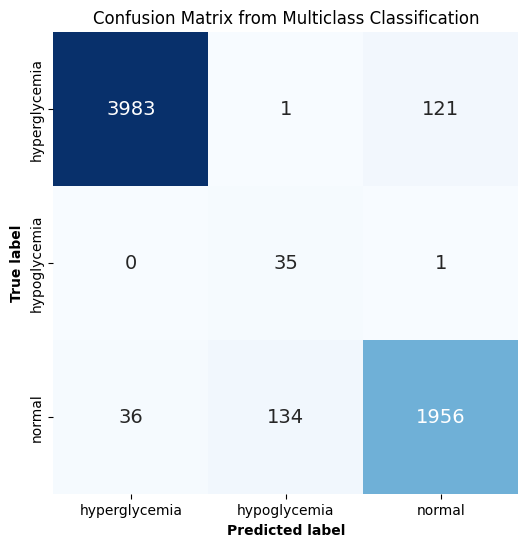

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 6))
sns.heatmap(
    cm,
    annot = True, annot_kws = {"size": 14},
    fmt = "d", cmap = "Blues",
    cbar = False,
    xticklabels = target_names,
    yticklabels = target_names
    )
plt.ylabel("True label", fontweight = "bold")
plt.xlabel("Predicted label", fontweight = "bold")
plt.title("Confusion Matrix from Multiclass Classification")
plt.show()

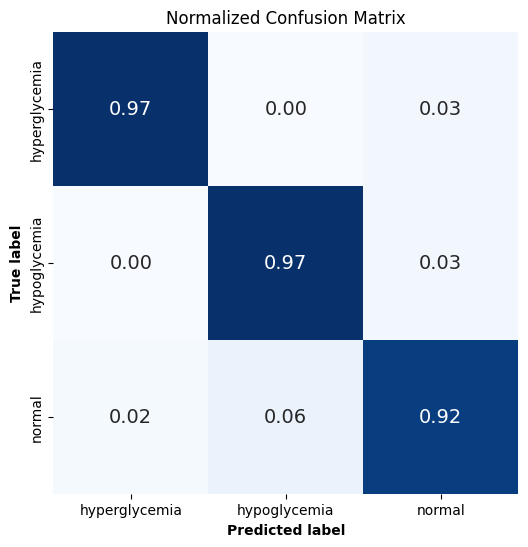

In [27]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,6))
sns.heatmap(
    cm_norm,
    annot=True, annot_kws={"size": 14},
    fmt='.2f',
    cmap='Blues', cbar = False,
    xticklabels= target_names,
    yticklabels= target_names
    )
plt.ylabel("True label", fontweight = "bold")
plt.xlabel("Predicted label", fontweight = "bold")
plt.title("Normalized Confusion Matrix")
plt.show()

### ⭐ What if we change the threshold?

In [48]:
thresholds = [.3, .5, .7, .9]

In [49]:
y_prob = model.predict_proba(X_test_scaled)

# check shape (0: hyperglycemia / 1: hypoglycemia / 2: normal)
print(y_probabilities.shape)

(6267, 3)


In [50]:
# extracting probabilities for each class
hyper_p = y_prob[:, 0]
hypo_p = y_prob[:, 1]
normal_p = y_prob[:, 2]

In [62]:
for t in thresholds:

  # resetting prediction array for this threshold
  y_pred_custom = np.zeros(len(y_prob), dtype = int)

  for i in range(len(y_prob)):

    # focusing on changing the probability for hypoglycemia
    if hypo_p[i] > t:
      y_pred_custom[i] = 1

    else:
      # if not, choose between hyperglycemia or normal
      if hyper_p[i] > normal_p[i]:
        y_pred_custom[i] = 0
      else:
        y_pred_custom[i] = 2

  # compute report
  report = classification_report(
      y_test,
      y_pred_custom,
      target_names = target_names
    )


  print(f"Threshold = {t}")
  print(report)

Threshold = 0.3
               precision    recall  f1-score   support

hyperglycemia       0.99      0.97      0.98      4105
 hypoglycemia       0.15      1.00      0.26        36
       normal       0.94      0.89      0.91      2126

     accuracy                           0.94      6267
    macro avg       0.69      0.95      0.72      6267
 weighted avg       0.97      0.94      0.95      6267

Threshold = 0.5
               precision    recall  f1-score   support

hyperglycemia       0.99      0.97      0.98      4105
 hypoglycemia       0.21      0.97      0.34        36
       normal       0.94      0.92      0.93      2126

     accuracy                           0.95      6267
    macro avg       0.71      0.95      0.75      6267
 weighted avg       0.97      0.95      0.96      6267

Threshold = 0.7
               precision    recall  f1-score   support

hyperglycemia       0.99      0.97      0.98      4105
 hypoglycemia       0.26      0.97      0.41        36
       nor

In [63]:
# making this as a function
def threshold_set(t):
  y_pred_custom = np.zeros(len(y_prob), dtype = int)

  for i in range(len(y_prob)):
    if hypo_p[i] > t:
      y_pred_custom[i] = 1

    else:
      if hyper_p[i] > normal_p[i]:
        y_pred_custom[i] = 0
      else:
        y_pred_custom[i] = 2

  return y_pred_custom

In [66]:
y_3 = threshold_set(.3)
y_5 = threshold_set(.5)
y_7 = threshold_set(.7)
y_9 = threshold_set(.9)

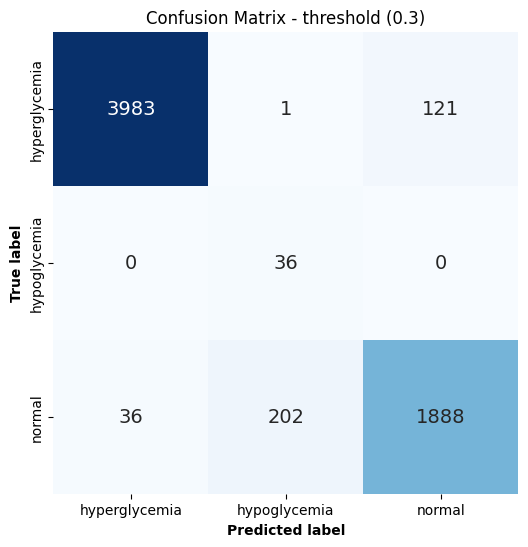

In [71]:
cm = confusion_matrix(y_test, y_3)

plt.figure(figsize = (6, 6))
sns.heatmap(
    cm,
    annot = True, annot_kws = {"size": 14},
    fmt = "d", cmap = "Blues",
    cbar = False,
    xticklabels = target_names,
    yticklabels = target_names
    )
plt.ylabel("True label", fontweight = "bold")
plt.xlabel("Predicted label", fontweight = "bold")
plt.title("Confusion Matrix - threshold (0.3)")
plt.show()

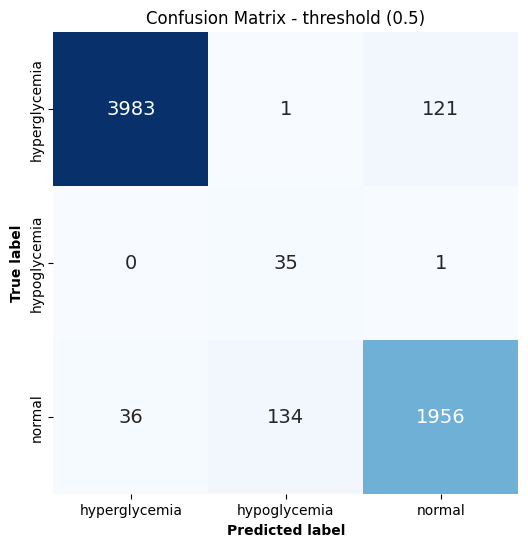

In [70]:
cm = confusion_matrix(y_test, y_5)

plt.figure(figsize = (6, 6))
sns.heatmap(
    cm,
    annot = True, annot_kws = {"size": 14},
    fmt = "d", cmap = "Blues",
    cbar = False,
    xticklabels = target_names,
    yticklabels = target_names
    )
plt.ylabel("True label", fontweight = "bold")
plt.xlabel("Predicted label", fontweight = "bold")
plt.title("Confusion Matrix - threshold (0.5)")
plt.show()

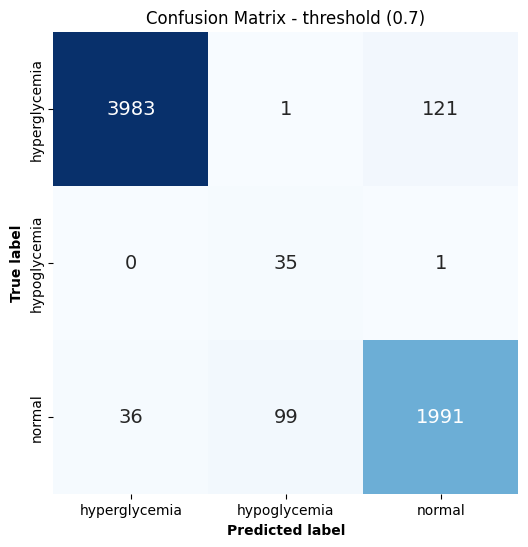

In [69]:
cm = confusion_matrix(y_test, y_7)

plt.figure(figsize = (6, 6))
sns.heatmap(
    cm,
    annot = True, annot_kws = {"size": 14},
    fmt = "d", cmap = "Blues",
    cbar = False,
    xticklabels = target_names,
    yticklabels = target_names
    )
plt.ylabel("True label", fontweight = "bold")
plt.xlabel("Predicted label", fontweight = "bold")
plt.title("Confusion Matrix - threshold (0.7)")
plt.show()

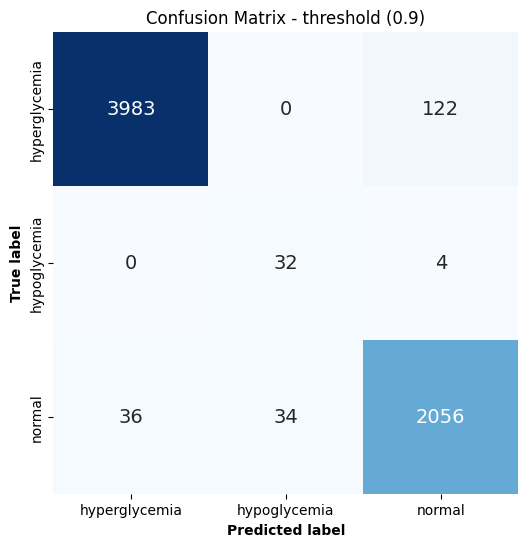

In [68]:
cm = confusion_matrix(y_test, y_9)

plt.figure(figsize = (6, 6))
sns.heatmap(
    cm,
    annot = True, annot_kws = {"size": 14},
    fmt = "d", cmap = "Blues",
    cbar = False,
    xticklabels = target_names,
    yticklabels = target_names
    )
plt.ylabel("True label", fontweight = "bold")
plt.xlabel("Predicted label", fontweight = "bold")
plt.title("Confusion Matrix - threshold (0.9)")
plt.show()